Nutrimix Example

In [1]:
import pandas as pd

# NutriMix

**Variable**
- $x_1$ = GranolaBar/minggu
- $x_2$ = ProteinBite/minggu

**Objective** (profit)
$$\max Z = 30x_1 + 50x_2$$

**Constraints**
$$
\begin{aligned}
2x_1 + 4x_2 &\le 80 \quad \text{(mixing)} \\
3x_1 + 2x_2 &\le 60 \quad \text{(baking)} \\
x_1 + 2x_2 &\le 50 \quad \text{(packaging)} \\
x_1, x_2 &\ge 0
\end{aligned}
$$

Visualize Constraints

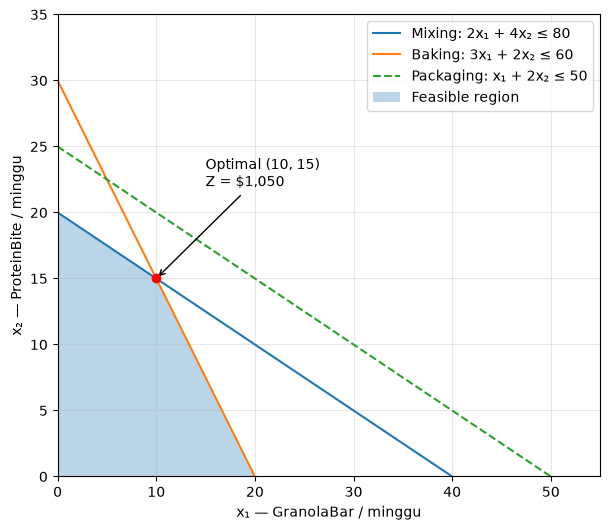

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 60, 400)

# tiap constraint diubah jadi x2 = ...
mixing = (80 - 2*x) / 4
baking = (60 - 3*x) / 2
packaging = (50 - x) / 2

plt.figure(figsize=(7, 6))
plt.plot(x, mixing, label="Mixing: 2x₁ + 4x₂ ≤ 80")
plt.plot(x, baking, label="Baking: 3x₁ + 2x₂ ≤ 60")
plt.plot(x, packaging, "--", label="Packaging: x₁ + 2x₂ ≤ 50")

# feasible region = di bawah semua garis sekaligus
batas_atas = np.clip(np.minimum.reduce([mixing, baking, packaging]), 0, None)
plt.fill_between(x, 0, batas_atas, alpha=0.3, label="Feasible region")

# titik optimal
plt.scatter(10, 15, color="red", zorder=5)
plt.annotate(r"Optimal (10, 15)" "\n" r"Z = \$1,050", (10, 15),
             xytext=(15, 22), arrowprops=dict(arrowstyle="->"))

plt.xlim(0, 55)
plt.ylim(0, 35)
plt.xlabel("x₁ — GranolaBar / minggu")
plt.ylabel("x₂ — ProteinBite / minggu")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
import numpy as np
import pandas as pd

from pulp import LpProblem, LpMaximize, LpVariable, value


In [4]:
products = ['GranolaBar', 'PoretinBite']
resources = ['mixing', 'baking', 'packaging']

profit = {
    'GranolaBar': 30,
    'ProteinBite': 50,
}

usage = {
    ('GranolaBar', 'mixing'): 2,
    ('GranolaBar', 'baking'): 3,
    ('GranolaBar', 'packaging'): 1,
    ('ProteinBite', 'mixing'): 4,
    ('ProteinBite', 'baking'): 2,
    ('ProteinBite', 'packaging'): 2,
}

capacity = {
    'mixing': 80,
    'baking': 60,
    'packaging': 50,
}

In [5]:
# Create problem

prob = LpProblem("Maximize profit", LpMaximize)
prob

/Users/ghifar/Documents/GitHub/linear-programming-marketing-budget-optimization/.venv/lib/python3.12/site-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Maximize_profit:
MAXIMIZE
None
VARIABLES

In [6]:
prob

Maximize_profit:
MAXIMIZE
None
VARIABLES

In [7]:
x1 = prob.add_variable("GranolaBar", lowBound=0, cat="Integer")
x2 = prob.add_variable("ProteinBite", lowBound=0, cat="Integer")

In [8]:
prob

Maximize_profit:
MAXIMIZE
None
VARIABLES

In [9]:
prob += 30*x1 + 50*x2, "Total_Profit"
prob

Maximize_profit:
MAXIMIZE
30*GranolaBar + 50*ProteinBite + 0
VARIABLES
0 <= GranolaBar Integer
0 <= ProteinBite Integer

In [10]:
prob += 2 * x1 + 4 * x2 <= 80, "Mixing Hour"
prob += 3 * x1 + 2 * x2 <= 60, "Baking Hour"
prob += 1 * x1 + 2 * x2 <= 50, "Packaging Hour"
prob

Maximize_profit:
MAXIMIZE
30*GranolaBar + 50*ProteinBite + 0
SUBJECT TO
Mixing_Hour: 2 GranolaBar + 4 ProteinBite <= 80

Baking_Hour: 3 GranolaBar + 2 ProteinBite <= 60

Packaging_Hour: GranolaBar + 2 ProteinBite <= 50

VARIABLES
0 <= GranolaBar Integer
0 <= ProteinBite Integer

In [19]:
# from pulp import HiGHS
prob.solve()

print(LpStatus[status])


Running HiGHS 1.13.0 (git hash: 1bce6d5): Copyright (c) 2026 under MIT licence terms
MIP has 3 rows; 2 cols; 6 nonzeros; 2 integer variables (0 binary)
Coefficient ranges:
  Matrix  [1e+00, 4e+00]
  Cost    [3e+01, 5e+01]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 8e+01]
Presolving model
3 rows, 2 cols, 6 nonzeros  0s
2 rows, 2 cols, 4 nonzeros  0s
2 rows, 2 cols, 4 nonzeros  0s
Presolve reductions: rows 2(-1); columns 2(-0); nonzeros 4(-2) 
Objective function is integral with scale 0.1

Solving MIP model with:
   2 rows
   2 cols (0 binary, 2 integer, 0 implied int., 0 continuous, 0 domain fixed)
   4 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

  

In [20]:
print("GranolaBar:", x1.value())
print("ProteinBite:", x2.value())
print("Revenue:", value(prob.objective))

GranolaBar: 10.000000000000002
ProteinBite: 14.999999999999998
Revenue: 1050.0


In [ ]:
# Setup: PuLP 4 + HiGHS
# - PuLP 4 creates variables with prob.add_variable(...)
# - CBC isn't bundled anymore, so use HiGHS as the solver
# - Solve with prob.solve(HiGHS(msg=False)); read status with LpStatus[status]
# Run once, then restart the kernel
!uv add pandas "pulp[highs]"